# **Bibliotecas**

In [ ]:
# Bibliotecas básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Funções**

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_cm(model, X, y, format='.3f'):
    """Função para exibir a matriz de confusão"""

    ConfusionMatrixDisplay.from_estimator(model, X, y,
                                          values_format=format,
                                          cmap='Blues',
                                          normalize='true')
    plt.show()

# **Dados**

In [ ]:
!gdown 1W8rgRotNTxF15njfzLM_AsRcIbmBxtfD --quiet

In [ ]:
# Leitura dos dados
df = pd.read_csv('heart_disease_small.csv')
print(df.shape)
df.head(3)

(54365, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,25.61,No,No,Yes,2.0,0.0,No,Female,75-79,White,No,Yes,Good,5.0,No,No,No
1,No,29.05,No,No,No,0.0,0.0,No,Male,45-49,White,No,Yes,Good,8.0,No,No,No
2,No,24.69,No,No,No,0.0,0.0,No,Female,30-34,Asian,No,Yes,Very good,7.0,No,No,No


In [ ]:
# Informações do conjunto de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54365 entries, 0 to 54364
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HeartDisease      54365 non-null  object 
 1   BMI               54365 non-null  float64
 2   Smoking           54365 non-null  object 
 3   AlcoholDrinking   54365 non-null  object 
 4   Stroke            54365 non-null  object 
 5   PhysicalHealth    54365 non-null  float64
 6   MentalHealth      54365 non-null  float64
 7   DiffWalking       54365 non-null  object 
 8   Sex               54365 non-null  object 
 9   AgeCategory       54365 non-null  object 
 10  Race              54365 non-null  object 
 11  Diabetic          54365 non-null  object 
 12  PhysicalActivity  54365 non-null  object 
 13  GenHealth         54365 non-null  object 
 14  SleepTime         54365 non-null  float64
 15  Asthma            54365 non-null  object 
 16  KidneyDisease     54365 non-null  object

In [ ]:
# Quantidade em cada classe
df.HeartDisease.value_counts()

,count
HeartDisease,
No,49762
Yes,4603


In [ ]:
# Codificando o label
from sklearn.preprocessing import LabelEncoder

le_label = LabelEncoder()
df.HeartDisease = le_label.fit_transform(df.HeartDisease)

In [ ]:
df.HeartDisease.value_counts()

,count
HeartDisease,
0,49762
1,4603


In [ ]:
df.duplicated().sum()

np.int64(780)

In [ ]:
df.drop_duplicates(keep='first', inplace=True, ignore_index=True)
df.shape

(53585, 18)

In [ ]:
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,25.61,No,No,Yes,2.0,0.0,No,Female,75-79,White,No,Yes,Good,5.0,No,No,No
1,0,29.05,No,No,No,0.0,0.0,No,Male,45-49,White,No,Yes,Good,8.0,No,No,No
2,0,24.69,No,No,No,0.0,0.0,No,Female,30-34,Asian,No,Yes,Very good,7.0,No,No,No
3,0,22.59,No,No,No,0.0,0.0,No,Male,75-79,White,No,Yes,Very good,8.0,No,No,No
4,0,30.23,No,No,No,0.0,1.0,No,Female,65-69,White,Yes,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53580,0,26.70,Yes,No,No,0.0,10.0,No,Female,70-74,Black,No,Yes,Good,8.0,No,No,No
53581,0,21.29,No,No,No,0.0,1.0,No,Female,35-39,White,No,Yes,Excellent,7.0,No,No,No
53582,0,34.70,No,No,Yes,0.0,5.0,No,Female,65-69,Black,No,No,Very good,6.0,No,No,No
53583,0,31.32,Yes,No,No,0.0,0.0,No,Male,25-29,Hispanic,No,Yes,Excellent,7.0,No,No,No


In [ ]:
y = df.HeartDisease
X = df.drop('HeartDisease', axis=1)

X

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,25.61,No,No,Yes,2.0,0.0,No,Female,75-79,White,No,Yes,Good,5.0,No,No,No
1,29.05,No,No,No,0.0,0.0,No,Male,45-49,White,No,Yes,Good,8.0,No,No,No
2,24.69,No,No,No,0.0,0.0,No,Female,30-34,Asian,No,Yes,Very good,7.0,No,No,No
3,22.59,No,No,No,0.0,0.0,No,Male,75-79,White,No,Yes,Very good,8.0,No,No,No
4,30.23,No,No,No,0.0,1.0,No,Female,65-69,White,Yes,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53580,26.70,Yes,No,No,0.0,10.0,No,Female,70-74,Black,No,Yes,Good,8.0,No,No,No
53581,21.29,No,No,No,0.0,1.0,No,Female,35-39,White,No,Yes,Excellent,7.0,No,No,No
53582,34.70,No,No,Yes,0.0,5.0,No,Female,65-69,Black,No,No,Very good,6.0,No,No,No
53583,31.32,Yes,No,No,0.0,0.0,No,Male,25-29,Hispanic,No,Yes,Excellent,7.0,No,No,No


In [ ]:
from sklearn.model_selection import train_test_split

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=10,
                                                    stratify=y
                                                    ) # Mantém a proporção das classes

print(f'X_train = {X_train.shape}, X_test = {X_test.shape}')
print(f'y_train = {y_train.shape}, y_test = {y_test.shape}')

X_train = (40188, 17), X_test = (13397, 17)
y_train = (40188,), y_test = (13397,)


In [ ]:
X_train

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
24673,27.44,No,No,No,10.0,0.0,No,Female,55-59,Black,Yes,No,Good,6.0,No,Yes,No
17596,20.33,No,No,No,30.0,0.0,No,Male,60-64,Other,No,No,Fair,8.0,No,No,No
457,17.22,No,No,No,3.0,4.0,No,Female,35-39,White,No,Yes,Good,6.0,No,No,No
13771,22.67,No,No,No,0.0,0.0,No,Female,35-39,Hispanic,Yes (during pregnancy),No,Good,10.0,No,No,No
46252,25.68,Yes,No,No,0.0,0.0,No,Male,60-64,White,No,Yes,Good,7.0,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16803,26.54,No,No,No,0.0,0.0,No,Male,30-34,Asian,No,Yes,Very good,7.0,No,No,No
50624,38.01,No,No,No,0.0,0.0,No,Male,50-54,White,No,Yes,Excellent,7.0,No,No,No
33748,24.94,No,No,No,0.0,2.0,No,Female,60-64,White,No,Yes,Excellent,7.0,No,No,No
26086,41.60,Yes,No,No,15.0,0.0,No,Female,55-59,White,Yes,Yes,Fair,6.0,No,No,Yes


In [ ]:
y.value_counts(normalize=True)

,proportion
HeartDisease,
0,0.914174
1,0.085826


In [ ]:
y_test.value_counts(normalize=True)

,proportion
HeartDisease,
0,0.91416
1,0.08584


In [ ]:
y_train.value_counts(normalize=True)

,proportion
HeartDisease,
0,0.914178
1,0.085822


In [ ]:
X_train

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
24673,27.44,No,No,No,10.0,0.0,No,Female,55-59,Black,Yes,No,Good,6.0,No,Yes,No
17596,20.33,No,No,No,30.0,0.0,No,Male,60-64,Other,No,No,Fair,8.0,No,No,No
457,17.22,No,No,No,3.0,4.0,No,Female,35-39,White,No,Yes,Good,6.0,No,No,No
13771,22.67,No,No,No,0.0,0.0,No,Female,35-39,Hispanic,Yes (during pregnancy),No,Good,10.0,No,No,No
46252,25.68,Yes,No,No,0.0,0.0,No,Male,60-64,White,No,Yes,Good,7.0,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16803,26.54,No,No,No,0.0,0.0,No,Male,30-34,Asian,No,Yes,Very good,7.0,No,No,No
50624,38.01,No,No,No,0.0,0.0,No,Male,50-54,White,No,Yes,Excellent,7.0,No,No,No
33748,24.94,No,No,No,0.0,2.0,No,Female,60-64,White,No,Yes,Excellent,7.0,No,No,No
26086,41.60,Yes,No,No,15.0,0.0,No,Female,55-59,White,Yes,Yes,Fair,6.0,No,No,Yes


In [ ]:
X_train.select_dtypes(include='object').columns

Index(['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex',
       'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

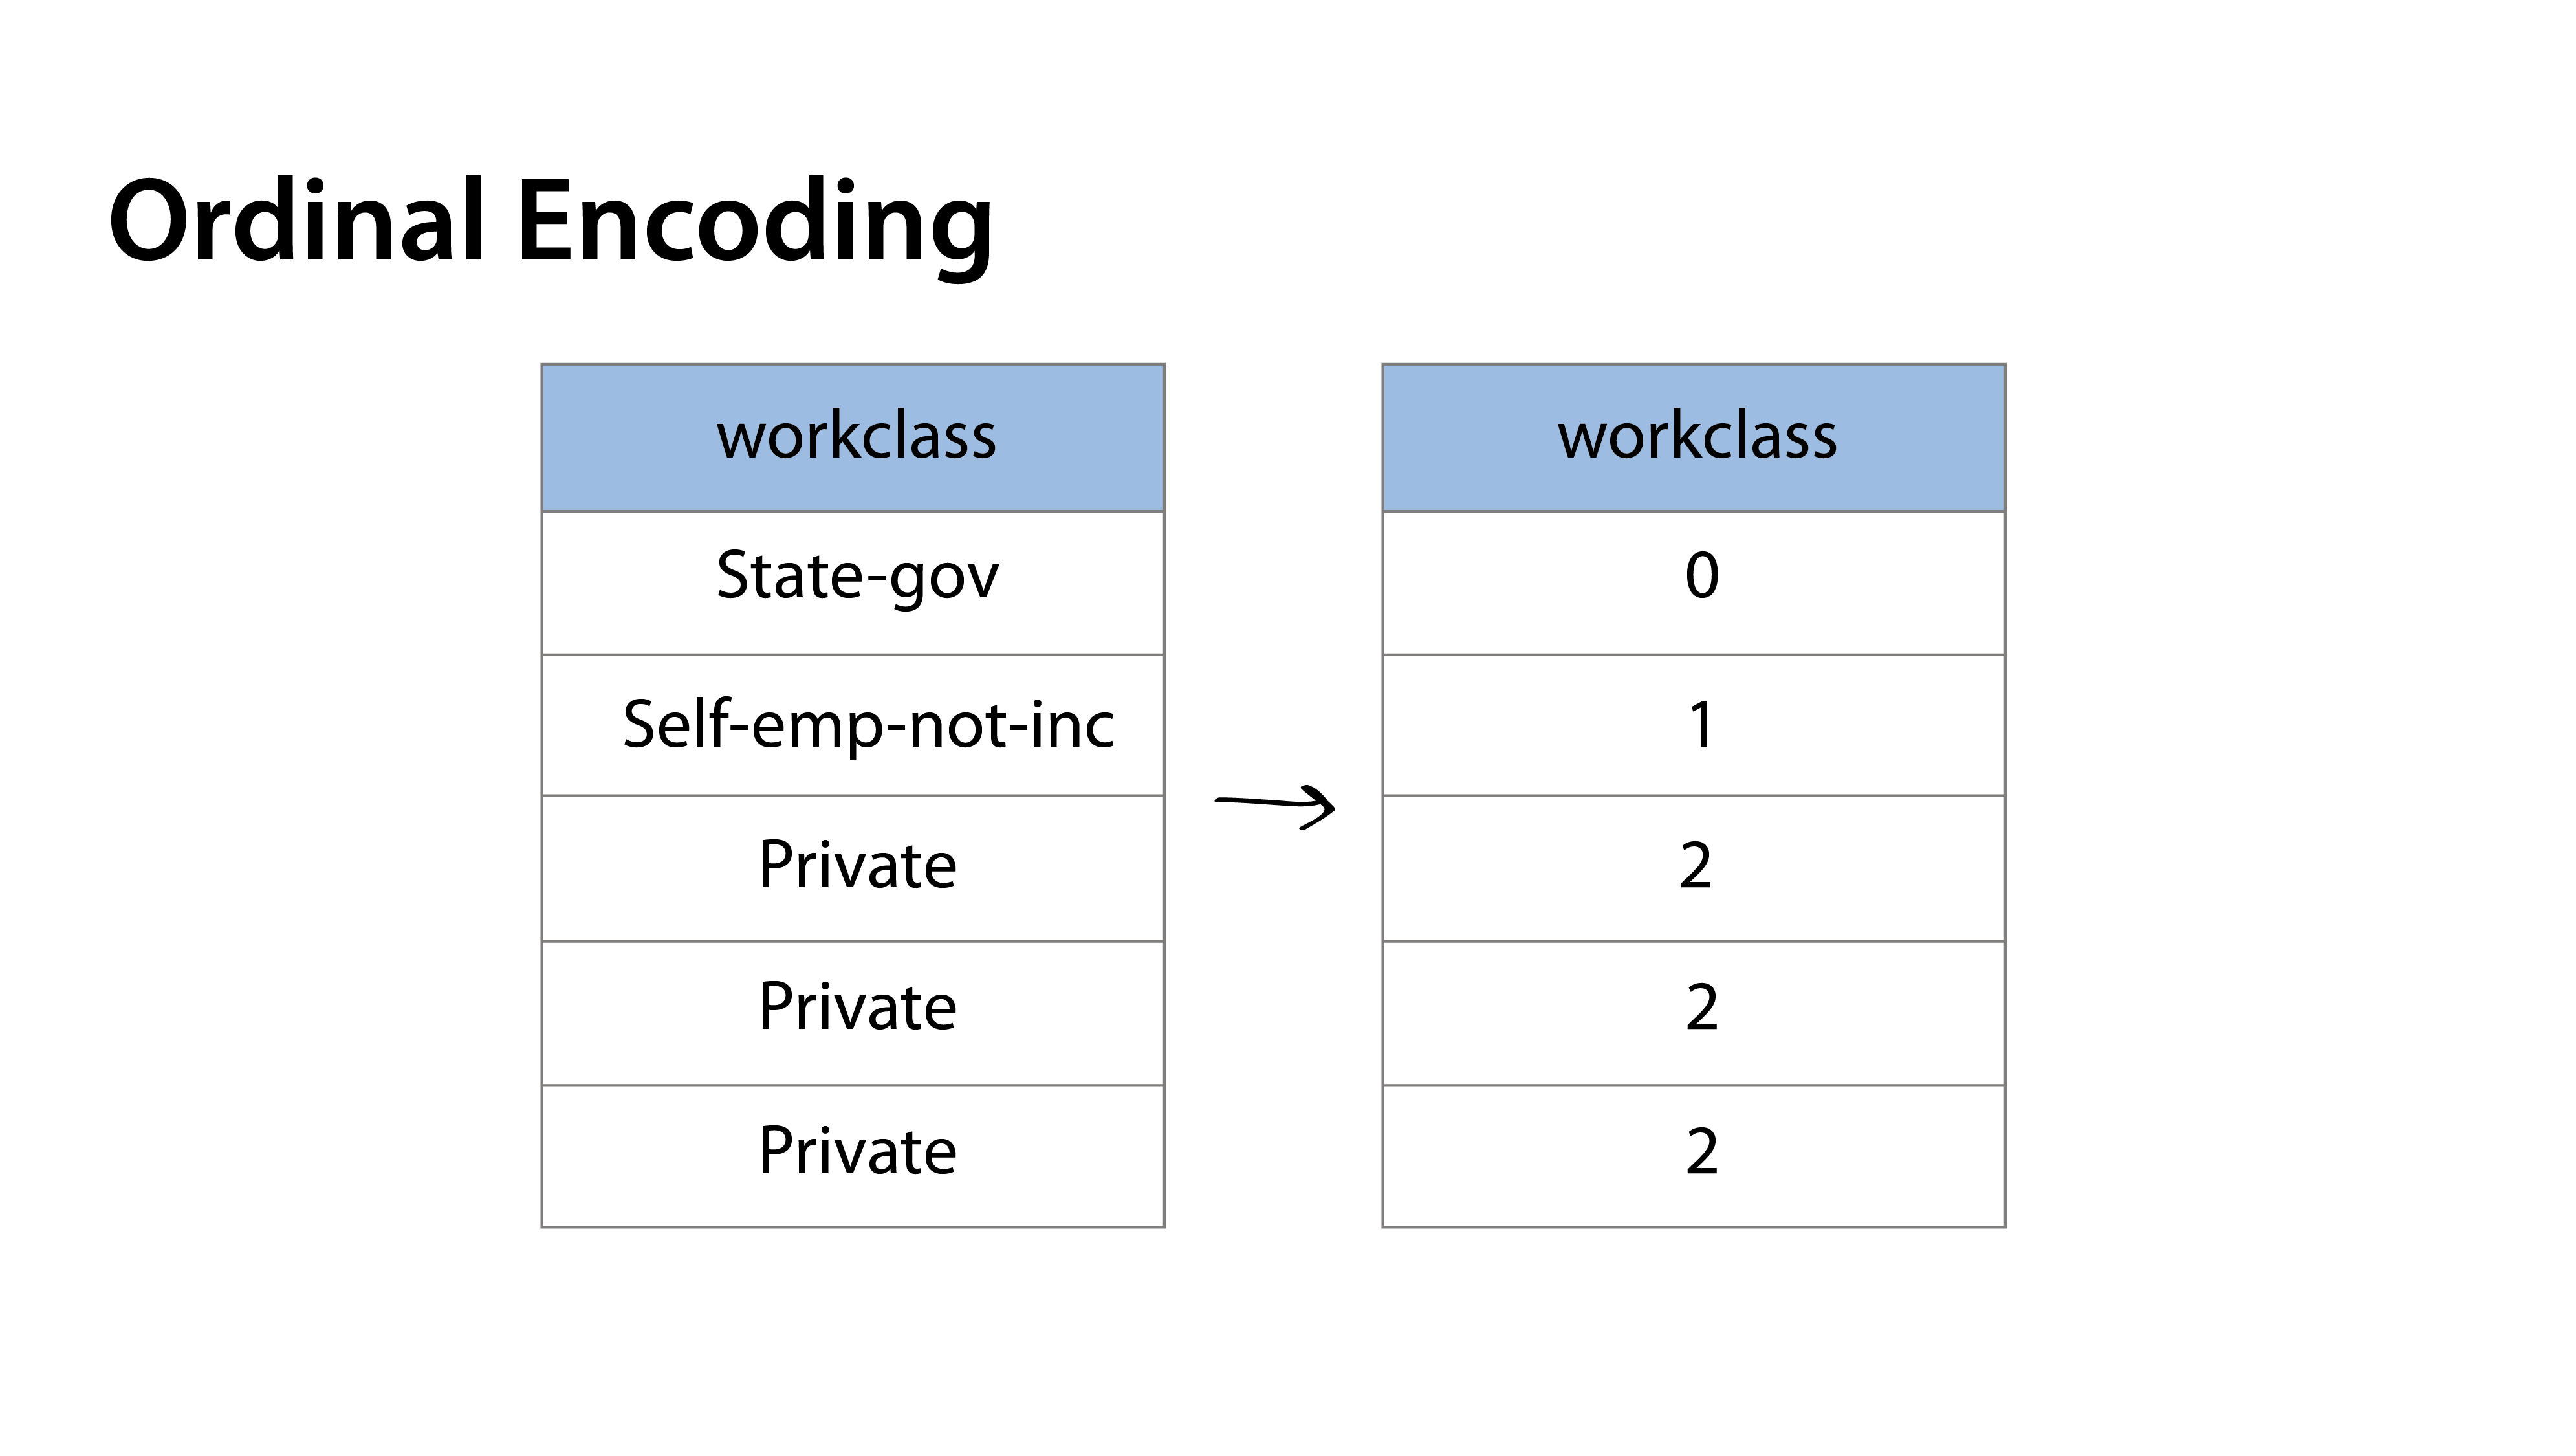

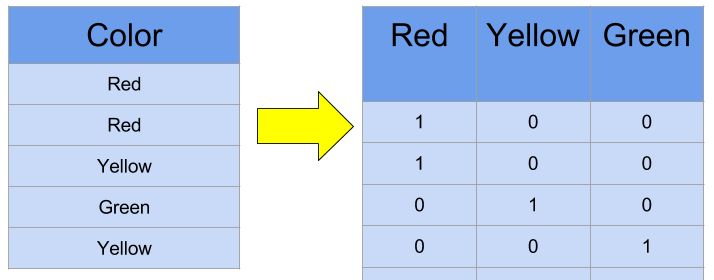

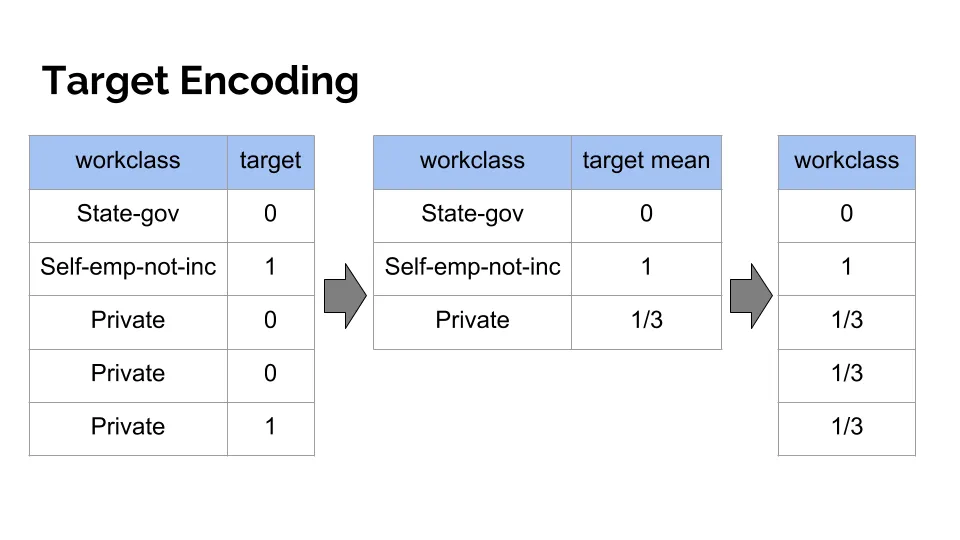

In [ ]:
np.sort(X_train.AgeCategory.unique())

array(['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54',
       '55-59', '60-64', '65-69', '70-74', '75-79', '80 or older'],
      dtype=object)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

oe_list = ['AgeCategory', 'Sex']
oe = {}

for col in oe_list:
    oe[col] = OrdinalEncoder(handle_unknown='use_encoded_value',
                             unknown_value=-1)
    oe[col].fit(X_train[[col]])
    X_train[col] = oe[col].transform(X_train[[col]])

X_train

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
24673,27.44,No,No,No,10.0,0.0,No,0.0,7.0,Black,Yes,No,Good,6.0,No,Yes,No
17596,20.33,No,No,No,30.0,0.0,No,1.0,8.0,Other,No,No,Fair,8.0,No,No,No
457,17.22,No,No,No,3.0,4.0,No,0.0,3.0,White,No,Yes,Good,6.0,No,No,No
13771,22.67,No,No,No,0.0,0.0,No,0.0,3.0,Hispanic,Yes (during pregnancy),No,Good,10.0,No,No,No
46252,25.68,Yes,No,No,0.0,0.0,No,1.0,8.0,White,No,Yes,Good,7.0,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16803,26.54,No,No,No,0.0,0.0,No,1.0,2.0,Asian,No,Yes,Very good,7.0,No,No,No
50624,38.01,No,No,No,0.0,0.0,No,1.0,6.0,White,No,Yes,Excellent,7.0,No,No,No
33748,24.94,No,No,No,0.0,2.0,No,0.0,8.0,White,No,Yes,Excellent,7.0,No,No,No
26086,41.60,Yes,No,No,15.0,0.0,No,0.0,7.0,White,Yes,Yes,Fair,6.0,No,No,Yes


In [ ]:
for col in oe_list:
    X_test[col] = oe[col].transform(X_test[[col]])

X_test

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
21997,27.57,Yes,No,No,1.0,2.0,No,1.0,9.0,White,No,Yes,Excellent,8.0,Yes,No,Yes
37861,23.75,No,No,No,0.0,0.0,No,1.0,2.0,White,No,Yes,Very good,8.0,No,No,No
27293,39.51,No,No,No,0.0,0.0,No,0.0,1.0,White,No,No,Excellent,6.0,No,No,No
26871,29.95,No,No,No,0.0,30.0,No,0.0,6.0,White,No,Yes,Very good,6.0,No,No,No
29200,21.95,Yes,No,No,5.0,0.0,No,0.0,0.0,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21198,32.45,Yes,No,No,0.0,2.0,No,0.0,4.0,Hispanic,No,Yes,Excellent,8.0,Yes,No,No
37276,34.01,No,No,No,0.0,0.0,No,0.0,9.0,White,No,Yes,Excellent,6.0,No,No,No
23390,35.87,Yes,No,Yes,0.0,0.0,Yes,1.0,9.0,White,No,No,Good,8.0,No,No,No
35926,29.01,Yes,No,No,0.0,0.0,No,1.0,2.0,White,No,Yes,Very good,5.0,No,No,No


In [ ]:
X_train.Diabetic.unique()

array(['Yes', 'No', 'Yes (during pregnancy)', 'No, borderline diabetes'],
      dtype=object)

In [ ]:
from sklearn.preprocessing import TargetEncoder

te_list = ['Race']
te = {}

for col in te_list:
    te[col] = TargetEncoder()
    te[col].fit(X_train[[col]], y_train)
    X_train[col] = te[col].transform(X_train[[col]])

X_train

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
24673,27.44,No,No,No,10.0,0.0,No,0.0,7.0,0.073225,Yes,No,Good,6.0,No,Yes,No
17596,20.33,No,No,No,30.0,0.0,No,1.0,8.0,0.095632,No,No,Fair,8.0,No,No,No
457,17.22,No,No,No,3.0,4.0,No,0.0,3.0,0.091612,No,Yes,Good,6.0,No,No,No
13771,22.67,No,No,No,0.0,0.0,No,0.0,3.0,0.055115,Yes (during pregnancy),No,Good,10.0,No,No,No
46252,25.68,Yes,No,No,0.0,0.0,No,1.0,8.0,0.091612,No,Yes,Good,7.0,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16803,26.54,No,No,No,0.0,0.0,No,1.0,2.0,0.031855,No,Yes,Very good,7.0,No,No,No
50624,38.01,No,No,No,0.0,0.0,No,1.0,6.0,0.091612,No,Yes,Excellent,7.0,No,No,No
33748,24.94,No,No,No,0.0,2.0,No,0.0,8.0,0.091612,No,Yes,Excellent,7.0,No,No,No
26086,41.60,Yes,No,No,15.0,0.0,No,0.0,7.0,0.091612,Yes,Yes,Fair,6.0,No,No,Yes


In [ ]:
X_train.Race.unique()

array([0.07322478, 0.09563234, 0.09161207, 0.05511492, 0.03185506,
       0.100726  ])

In [ ]:
for col in te_list:
    X_test[col] = te[col].transform(X_test[[col]])

X_test

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
21997,27.57,Yes,No,No,1.0,2.0,No,1.0,9.0,0.091612,No,Yes,Excellent,8.0,Yes,No,Yes
37861,23.75,No,No,No,0.0,0.0,No,1.0,2.0,0.091612,No,Yes,Very good,8.0,No,No,No
27293,39.51,No,No,No,0.0,0.0,No,0.0,1.0,0.091612,No,No,Excellent,6.0,No,No,No
26871,29.95,No,No,No,0.0,30.0,No,0.0,6.0,0.091612,No,Yes,Very good,6.0,No,No,No
29200,21.95,Yes,No,No,5.0,0.0,No,0.0,0.0,0.091612,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21198,32.45,Yes,No,No,0.0,2.0,No,0.0,4.0,0.055115,No,Yes,Excellent,8.0,Yes,No,No
37276,34.01,No,No,No,0.0,0.0,No,0.0,9.0,0.091612,No,Yes,Excellent,6.0,No,No,No
23390,35.87,Yes,No,Yes,0.0,0.0,Yes,1.0,9.0,0.091612,No,No,Good,8.0,No,No,No
35926,29.01,Yes,No,No,0.0,0.0,No,1.0,2.0,0.091612,No,Yes,Very good,5.0,No,No,No


In [ ]:
X_train.Smoking.unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe_list = ['Diabetic']

ohe = OneHotEncoder(drop='first', handle_unknown='ignore')

ohe.fit(X_train[ohe_list])

aux = ohe.transform(X_train[ohe_list])
aux

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6375 stored elements and shape (40188, 3)>

In [ ]:
ohe.get_feature_names_out()

array(['Diabetic_No, borderline diabetes', 'Diabetic_Yes',
       'Diabetic_Yes (during pregnancy)'], dtype=object)

In [ ]:
df_aux = pd.DataFrame(aux.toarray(), columns=ohe.get_feature_names_out(),
                      index=X_train.index
                      )
df_aux

,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
24673,0.0,1.0,0.0
17596,0.0,0.0,0.0
457,0.0,0.0,0.0
13771,0.0,0.0,1.0
46252,0.0,0.0,0.0
...,...,...,...
16803,0.0,0.0,0.0
50624,0.0,0.0,0.0
33748,0.0,0.0,0.0
26086,0.0,1.0,0.0


In [ ]:
X_train_ohe = X_train.merge(df_aux, left_index=True, right_index=True, how='left')
X_train_ohe

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
24673,27.44,No,No,No,10.0,0.0,No,0.0,7.0,0.073225,Yes,No,Good,6.0,No,Yes,No,0.0,1.0,0.0
17596,20.33,No,No,No,30.0,0.0,No,1.0,8.0,0.095632,No,No,Fair,8.0,No,No,No,0.0,0.0,0.0
457,17.22,No,No,No,3.0,4.0,No,0.0,3.0,0.091612,No,Yes,Good,6.0,No,No,No,0.0,0.0,0.0
13771,22.67,No,No,No,0.0,0.0,No,0.0,3.0,0.055115,Yes (during pregnancy),No,Good,10.0,No,No,No,0.0,0.0,1.0
46252,25.68,Yes,No,No,0.0,0.0,No,1.0,8.0,0.091612,No,Yes,Good,7.0,No,No,Yes,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16803,26.54,No,No,No,0.0,0.0,No,1.0,2.0,0.031855,No,Yes,Very good,7.0,No,No,No,0.0,0.0,0.0
50624,38.01,No,No,No,0.0,0.0,No,1.0,6.0,0.091612,No,Yes,Excellent,7.0,No,No,No,0.0,0.0,0.0
33748,24.94,No,No,No,0.0,2.0,No,0.0,8.0,0.091612,No,Yes,Excellent,7.0,No,No,No,0.0,0.0,0.0
26086,41.60,Yes,No,No,15.0,0.0,No,0.0,7.0,0.091612,Yes,Yes,Fair,6.0,No,No,Yes,0.0,1.0,0.0


In [ ]:
X_train_ohe.drop(columns=['Diabetic'], inplace=True)

In [ ]:
X_train_ohe

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
24673,27.44,No,No,No,10.0,0.0,No,0.0,7.0,0.073225,No,Good,6.0,No,Yes,No,0.0,1.0,0.0
17596,20.33,No,No,No,30.0,0.0,No,1.0,8.0,0.095632,No,Fair,8.0,No,No,No,0.0,0.0,0.0
457,17.22,No,No,No,3.0,4.0,No,0.0,3.0,0.091612,Yes,Good,6.0,No,No,No,0.0,0.0,0.0
13771,22.67,No,No,No,0.0,0.0,No,0.0,3.0,0.055115,No,Good,10.0,No,No,No,0.0,0.0,1.0
46252,25.68,Yes,No,No,0.0,0.0,No,1.0,8.0,0.091612,Yes,Good,7.0,No,No,Yes,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16803,26.54,No,No,No,0.0,0.0,No,1.0,2.0,0.031855,Yes,Very good,7.0,No,No,No,0.0,0.0,0.0
50624,38.01,No,No,No,0.0,0.0,No,1.0,6.0,0.091612,Yes,Excellent,7.0,No,No,No,0.0,0.0,0.0
33748,24.94,No,No,No,0.0,2.0,No,0.0,8.0,0.091612,Yes,Excellent,7.0,No,No,No,0.0,0.0,0.0
26086,41.60,Yes,No,No,15.0,0.0,No,0.0,7.0,0.091612,Yes,Fair,6.0,No,No,Yes,0.0,1.0,0.0


In [ ]:
# One Hot Encoding
from sklearn.preprocessing import OneHotEncoder

ohe_list = [#'Diabetic',
            'Race'] # Colunas para OneHotEncoder
ohe = dict()

X_train_ohe = X_train.copy()
X_test_ohe = X_test.copy()

for col in ohe_list:

    ## Criação e treinamento do OneHotEncoder
    ohe[col] = OneHotEncoder(handle_unknown='ignore', drop='first')
    ohe[col].fit(X_train_ohe[[col]])

    ## Dados de treino
    results_train = ohe[col].transform(X_train_ohe[[col]]).toarray()
    df_aux = pd.DataFrame(results_train,
                          columns=ohe[col].get_feature_names_out(), # 'coluna_categoria' como nome da coluna
                          index=X_train_ohe[col].index)
    X_train_ohe = X_train_ohe.merge(df_aux, how='left',
                                    left_index=True,
                                    right_index=True)

    ## Dados de teste
    results_test = ohe[col].transform(X_test_ohe[[col]]).toarray()
    df_aux = pd.DataFrame(results_test,
                          columns=ohe[col].get_feature_names_out(),
                          index=X_test_ohe[col].index)
    X_test_ohe = X_test_ohe.merge(df_aux, how='left',
                                  left_index=True,
                                  right_index=True)

# Drop das colunas originais
X_train_ohe.drop(columns=ohe_list, inplace=True)
X_test_ohe.drop(columns=ohe_list, inplace=True)

X_train_ohe.shape, X_test_ohe.shape